In [1]:
# ------------------------------
# Libraries & Config
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Stationarity test
from statsmodels.tsa.stattools import adfuller

# Simple change point detection
import ruptures as rpt

# Config
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')


In [2]:
# ------------------------------
# Helper Functions
# ------------------------------

def load_brent_data(filepath: str) -> pd.DataFrame:
    """Load and preprocess Brent oil price CSV."""
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        raise FileNotFoundError(f"File not found: {filepath}")
    except Exception as e:
        raise RuntimeError(f"Error loading file: {e}")
    
    if 'Date' not in df.columns or 'Price' not in df.columns:
        raise ValueError("CSV must contain 'Date' and 'Price' columns")
    
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df = df.sort_values('Date').reset_index(drop=True)
    return df


def compute_log_returns(df: pd.DataFrame) -> pd.DataFrame:
    """Compute daily log returns."""
    df['Log_Return'] = np.log(df['Price']).diff()
    df = df.dropna().reset_index(drop=True)
    return df


def plot_series(df: pd.DataFrame, column: str, title: str, color='blue'):
    """Plot a time series column."""
    plt.figure(figsize=(15,6))
    plt.plot(df['Date'], df[column], color=color)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(column)
    plt.grid(True)
    plt.show()


def perform_adf_test(series: pd.Series):
    """Augmented Dickey-Fuller stationarity test."""
    result = adfuller(series, autolag='AIC')
    print("ADF Statistic: {:.4f}".format(result[0]))
    print("p-value: {:.4f}".format(result[1]))
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("=> Series is likely stationary (reject H0)")
    else:
        print("=> Series is non-stationary (fail to reject H0)")
    return result


def detect_change_points(series: pd.Series, model="l2", pen=10):
    """Basic change point detection using ruptures."""
    algo = rpt.Pelt(model=model).fit(series.values)
    change_points = algo.predict(pen=pen)
    return change_points


def plot_change_points(series: pd.Series, change_points: list, title="Detected Change Points"):
    """Plot series with detected change points."""
    plt.figure(figsize=(15,6))
    plt.plot(series.index, series.values, color='orange')
    for cp in change_points[:-1]:  # last index is end
        plt.axvline(x=cp, color='red', linestyle='--', alpha=0.7)
    plt.title(title)
    plt.xlabel("Index")
    plt.ylabel(series.name)
    plt.grid(True)
    plt.show()


In [3]:
# ------------------------------
# Load Data
# ------------------------------
df = load_brent_data("../data/raw/BrentOilPrices.csv")

# Quick overview
print(df.info())
print(df['Price'].describe())

# Preview
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB
None
count    9011.000000
mean       48.420782
std        32.860110
min         9.100000
25%        19.050000
50%        38.570000
75%        70.090000
max       143.950000
Name: Price, dtype: float64


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


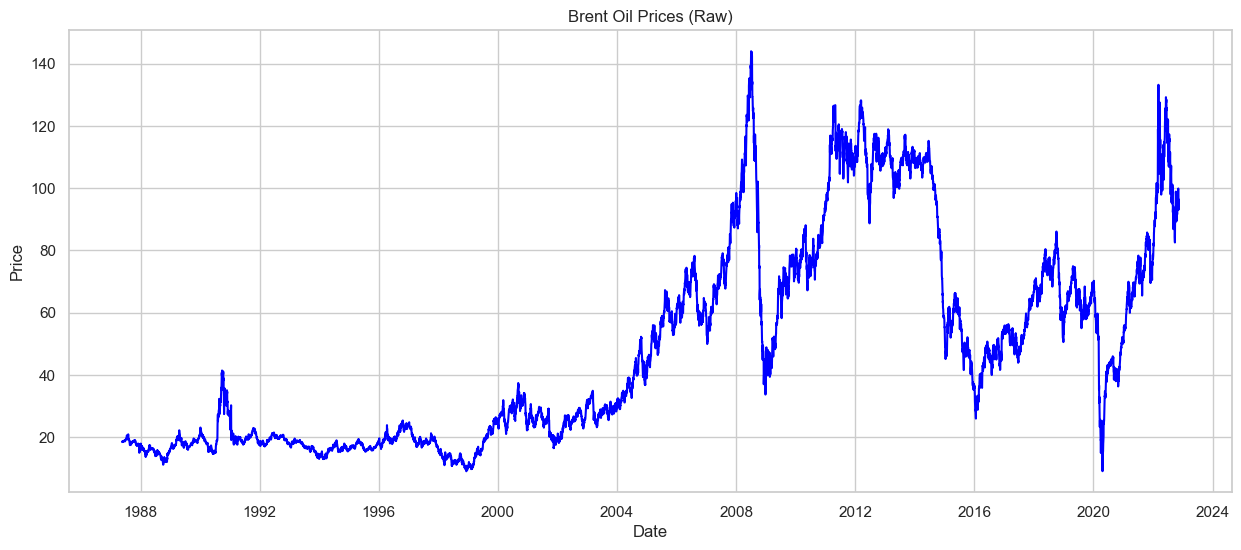

In [4]:
# ------------------------------
# Plot raw Brent prices
# ------------------------------
plot_series(df, 'Price', "Brent Oil Prices (Raw)")


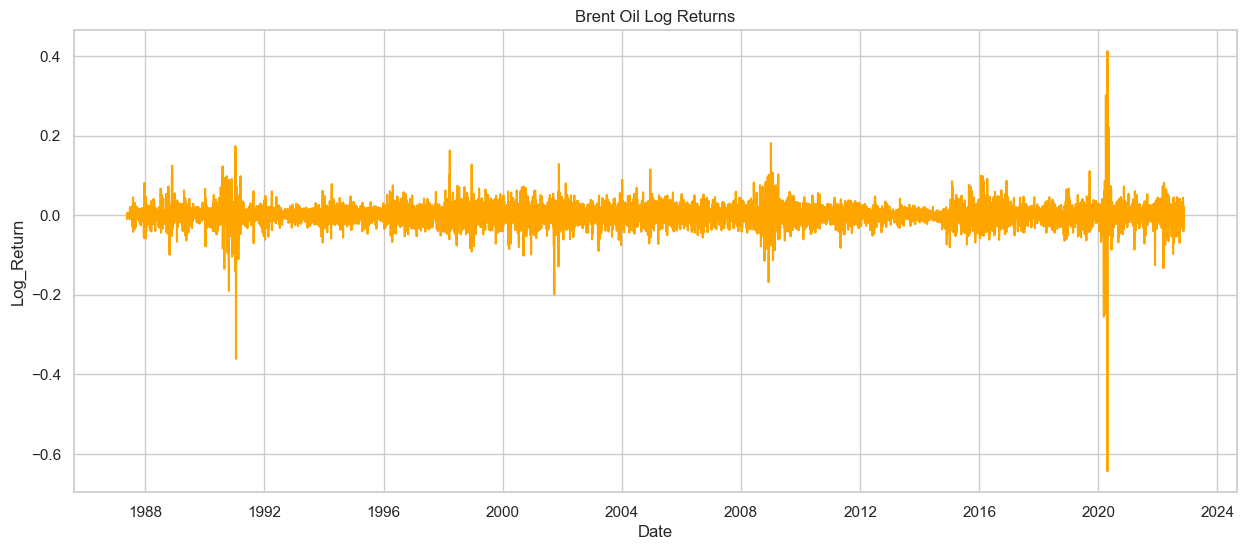

count    9010.000000
mean        0.000179
std         0.025532
min        -0.643699
25%        -0.011154
50%         0.000402
75%         0.012127
max         0.412023
Name: Log_Return, dtype: float64


In [5]:
# ------------------------------
# Compute log returns
# ------------------------------
df_returns = compute_log_returns(df)

# Preview
df_returns.head()

# Plot log returns
plot_series(df_returns, 'Log_Return', "Brent Oil Log Returns", color='orange')

# Statistics
print(df_returns['Log_Return'].describe())


In [6]:
# ------------------------------
# ADF Stationarity Test
# ------------------------------
print("\nADF Test on Log Returns:")
adf_result = perform_adf_test(df_returns['Log_Return'])



ADF Test on Log Returns:
ADF Statistic: -16.4271
p-value: 0.0000
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669
=> Series is likely stationary (reject H0)


In [7]:
# ------------------------------
# Detect structural breaks
# ------------------------------
change_points = detect_change_points(df_returns['Log_Return'], pen=10)
print(f"Detected change points at indices: {change_points}")


Detected change points at indices: [9010]


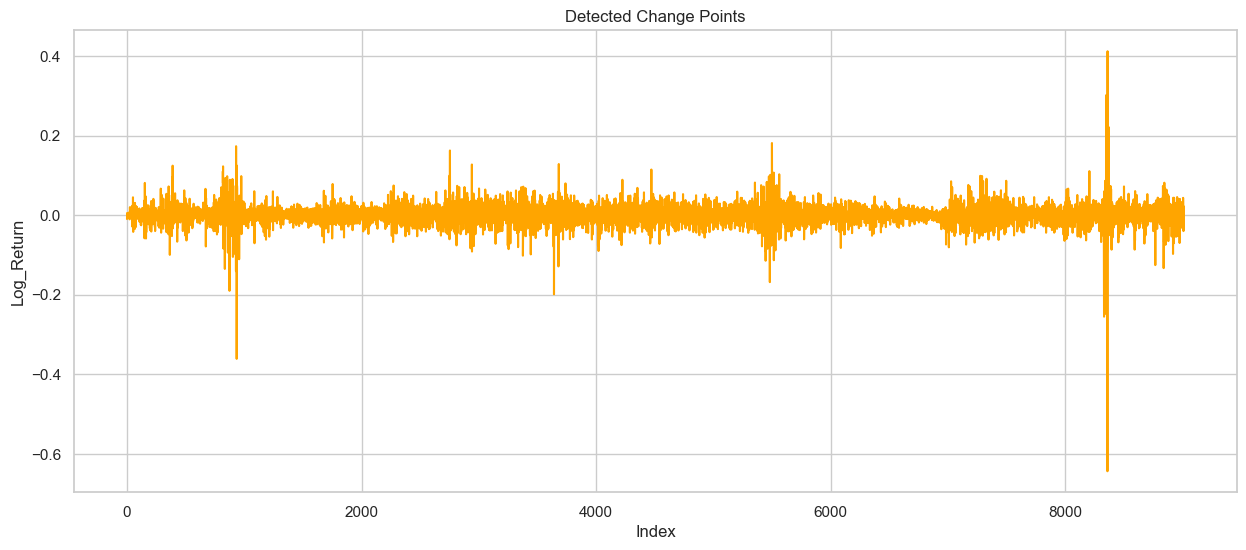

In [8]:
# ------------------------------
# Plot detected change points
# ------------------------------
plot_change_points(df_returns['Log_Return'], change_points)


### Linking Change Points to Real-World Events

Detected change points will be compared against a curated dataset of major geopolitical, OPEC, and macroeconomic events (`../data/oil_market_events.csv`). 
By aligning the dates of detected structural breaks with event start dates, we can form hypotheses about which events may have influenced Brent oil prices.

The CSV contains columns such as:

- `Date` : approximate start date of the event
- `Event` : short description of the geopolitical/economic/OPEC event
- `Category` : type of event (Geopolitical, OPEC, Economic)


In [9]:
events_raw = pd.read_csv("../data/oil_market_events.csv")
print(events_raw.columns)
events_raw.head()


Index(['date', 'event', 'category', 'description'], dtype='object')


,date,event,category,description
0,1990-08-02,Gulf War Begins,Geopolitical Conflict,Iraq invades Kuwait causing major disruption t...
1,2003-03-20,Iraq War Begins,Geopolitical Conflict,US-led invasion affecting Middle East oil prod...
2,2008-09-15,Global Financial Crisis,Economic Shock,Collapse of Lehman Brothers triggering global ...
3,2010-12-17,Arab Spring Begins,Geopolitical Conflict,Political unrest across Middle East and North ...
4,2011-02-15,Libyan Civil War,Geopolitical Conflict,Severe disruption of Libyan oil exports


# Assumptions & Communication Strategy

## Key Assumptions
1. Market prices reflect available information efficiently.
2. Structural changes can be approximated by discrete change points.
3. Event dates are approximate reference points for comparison.
4. Log returns are more suitable for statistical modeling.
5. External influences (macro, speculators) are unmodeled.

## Limitations
- Correlation ≠ causation: alignment suggests association, not proof.
- Overlapping events complicate attribution.
- Model simplicity may not capture variance-only changes or gradual shifts.
- Sensitivity to prior choices and modeling assumptions.
- Data limited to daily prices; intraday or supply-demand details are missing.

## Communication Strategy
- Policymakers: PDF report / executive summary
- Investors & Analysts: Interactive dashboard
- Energy companies: Visual analytics & key metrics
- Technical teams: Jupyter notebooks & GitHub repository
- General audience: Blog-style report


In [10]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [11]:
# Load data
df = pd.read_csv("../data/raw/BrentOilPrices.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")


In [12]:
monthly = (
    df.set_index("Date")["Price"]
    .resample("M")
    .mean()
    .dropna()
)

dates = monthly.index
prices = monthly.values


In [13]:
returns = np.log(prices[1:] / prices[:-1])
dates = dates[1:]
time_idx = np.arange(len(returns))
n = len(returns)


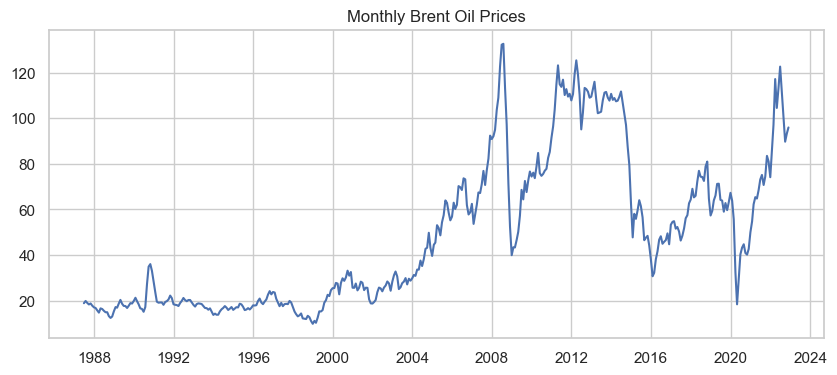

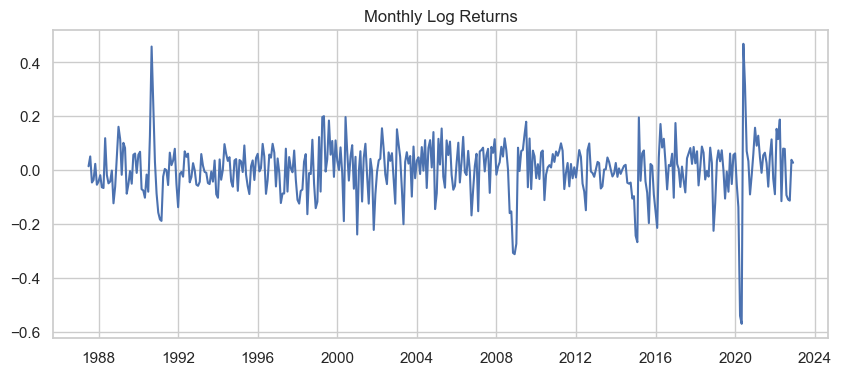

In [14]:
plt.figure(figsize=(10,4))
plt.plot(dates, prices[1:])
plt.title("Monthly Brent Oil Prices")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(dates, returns)
plt.title("Monthly Log Returns")
plt.show()


In [22]:
with pm.Model() as change_point_model:

    # Discrete change point
    tau = pm.DiscreteUniform("tau", lower=0, upper=n-1)

    # Regime means
    mu_1 = pm.Normal("mu_1", mu=0.0, sigma=0.05)
    mu_2 = pm.Normal("mu_2", mu=0.0, sigma=0.05)

    # Shared volatility
    sigma = pm.HalfNormal("sigma", sigma=0.05)

    # Switch
    mu = pm.math.switch(time_idx <= tau, mu_1, mu_2)

    # Likelihood
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=returns)

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        cores=1,
        target_accept=0.9,
        return_inferencedata=True
    )


Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

KeyError: 0

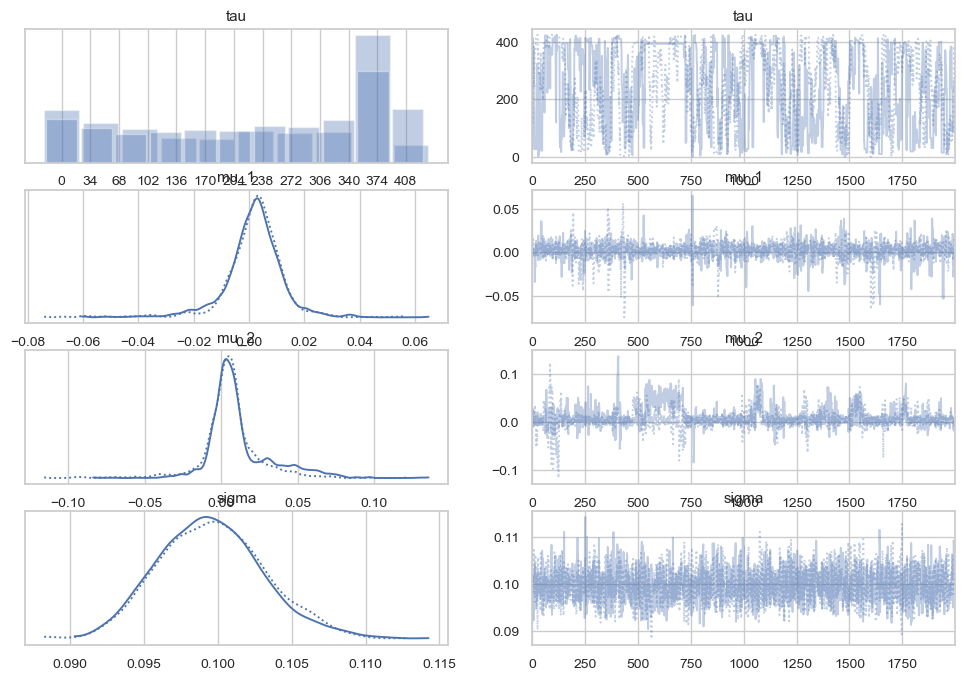

In [23]:
az.summary(trace)
az.plot_trace(trace, var_names=["tau", "mu_1", "mu_2", "sigma"])
plt.show()


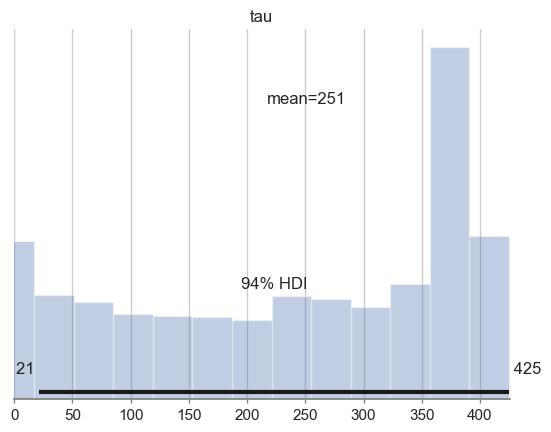

In [24]:
az.plot_posterior(trace, var_names=["tau"])
plt.show()


In [27]:
tau_mean = int(trace.posterior["tau"].mean().values)
change_date = dates[tau_mean]
change_date


Timestamp('2008-04-30 00:00:00')

In [32]:
df_dashboard = df_returns[["Date", "Price", "Log_Return"]].copy()
df_dashboard.columns = ["date", "price", "log_return"]

df_dashboard.to_csv(
    "../backend/data/brent_prices.csv",
    index=False
)


In [31]:
mu1_samples = trace.posterior["mu_1"].values.flatten()
mu2_samples = trace.posterior["mu_2"].values.flatten()
tau_samples = trace.posterior["tau"].values.flatten()

mu1_mean = mu1_samples.mean()
mu2_mean = mu2_samples.mean()

tau_mean = int(tau_samples.mean())
change_date = dates[tau_mean]

change_point_df = pd.DataFrame({
    "change_date": [change_date],
    "mu_before": [mu1_mean],
    "mu_after": [mu2_mean],
    "relative_change_pct": [
        ((mu2_mean - mu1_mean) / abs(mu1_mean)) * 100
    ]
})

change_point_df.to_csv(
    "../backend/data/change_points.csv",
    index=False
)
